<a href="https://colab.research.google.com/github/Shashwat-Raj/Ascendeum_Assignment_Task/blob/main/3_Tensorflow_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TensorFlow Neural Networks: Complete Tutorial Guide

## Table of Contents
1. [Introduction & Setup](#introduction--setup)
2. [TensorFlow Basics](#tensorflow-basics)
3. [Tensor Operations](#tensor-operations)
4. [Building Your First Neural Network](#building-your-first-neural-network)
5. [Layers and Activation Functions](#layers-and-activation-functions)
6. [Loss Functions and Optimizers](#loss-functions-and-optimizers)
7. [Training Pipeline](#training-pipeline)
8. [Industry Example: Customer Churn Prediction](#industry-example-customer-churn-prediction)
9. [Advanced Techniques](#advanced-techniques)
10. [Model Evaluation and Metrics](#model-evaluation-and-metrics)



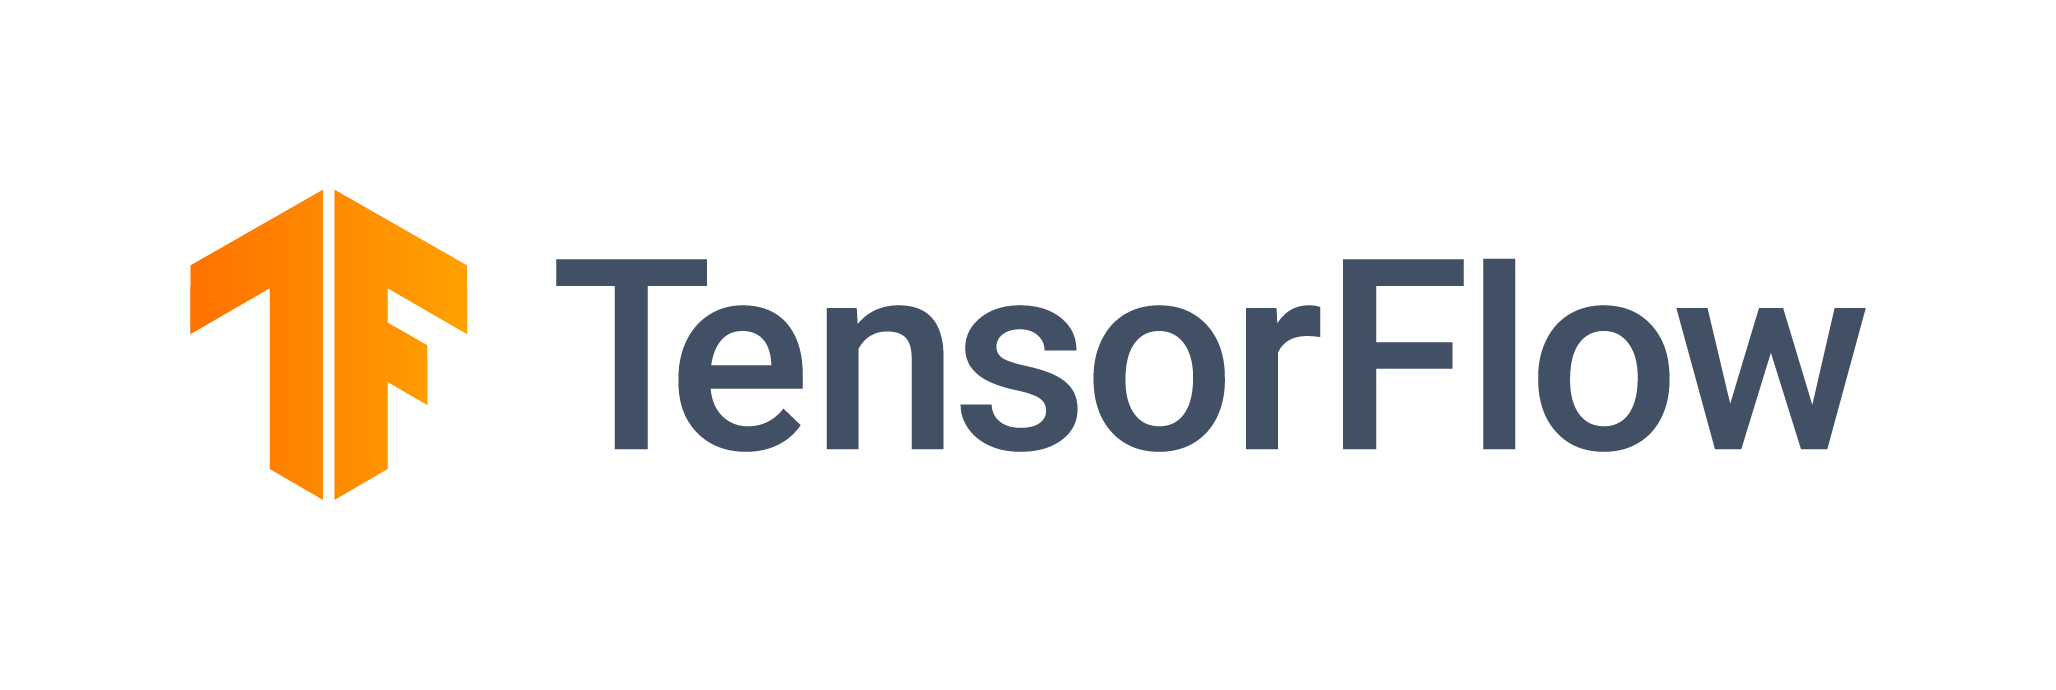

## 0. What Is TensorFlow?

**Simpler Take:**
TensorFlow is an open-source toolkit (think of it like a super-smart toolbox) for building and deploying machine learning—especially neural networks. It covers everything from cleaning your data to deploying models live.

**Industry Example:**
Imagine a ride-sharing app like Ola or Uber. TensorFlow can be used to build models that predict surge pricing or estimate arrival times. You train models on past ride data, fine-tune hyperparameters, and then serve the trained models in the app to compute estimates in real time.

---

## 1. Why Use TensorFlow?

**Simpler Take:**
You don’t build machine learning tools from scratch—TensorFlow has tons of ready-to-use building blocks that speed things up and reduce mistakes.

**Industry Example:**
In e-commerce, models for product recommendations or fraud detection must be reliable and scalable. Teams rely on TensorFlow’s high-level APIs like Keras to rapidly prototype, while still having access to low‑level ops for optimizing performance.

---

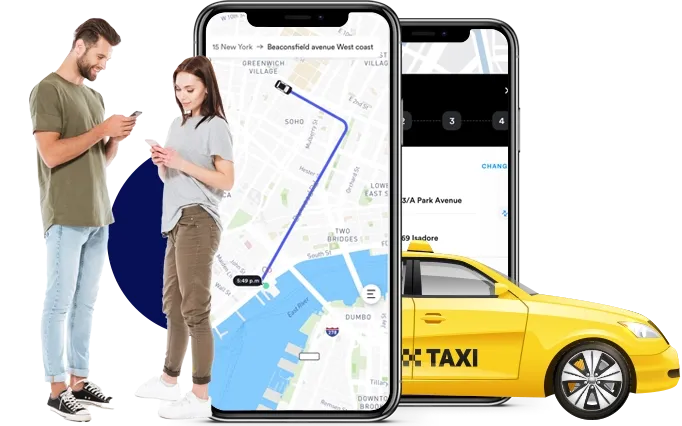

## 2. What We're Going to Cover

The guide introduces:

* **Tensors** – The main data objects.
* **Tensor info** – Shape, rank, size.
* **Tensor operations** – Math & math-like manipulations.
* **Tensors + NumPy** – How they compare and cooperate.
* **@tf.function** – Speeds up your code by turning it into optimized graphs.
* **GPU usage** – Accelerate operations using hardware.

**Industry Example:**
For image classification (like spotting product defects), you:

1. Load photos → convert to tensor form.
2. Peek at shapes to ensure dimensions match.
3. Preprocess (normalize, resize) using tensor ops.
4. Add `@tf.function` to speed up batch preprocessing.
5. Train using GPUs for efficient parallel computation.

---

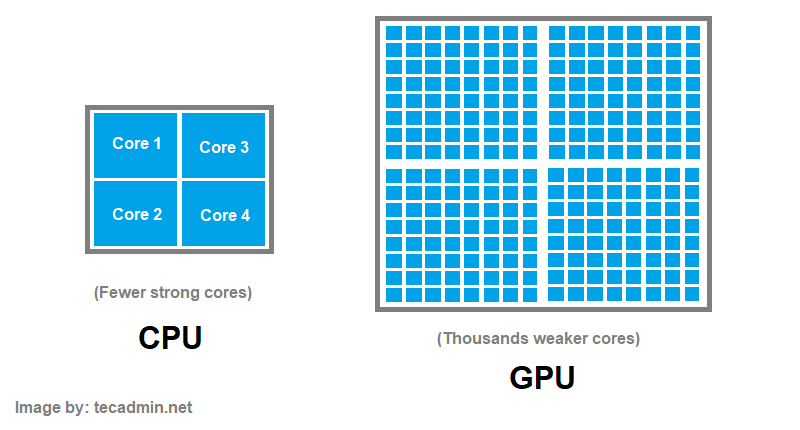

## 3. Introduction to Tensors

**Simpler Take:**
Tensors are just multi-dimensional arrays—just like NumPy arrays—used to represent numbers, images, text, any data.

**Industry Example:**

* **Scalar (0D):** A single brightness value: `tf.constant(0.75)`
* **Vector (1D):** A list of daily temperatures.
* **Matrix (2D):** A grayscale image’s pixel grid.
* **3D Tensor:** Color image with height, width, and RGB channels.

---

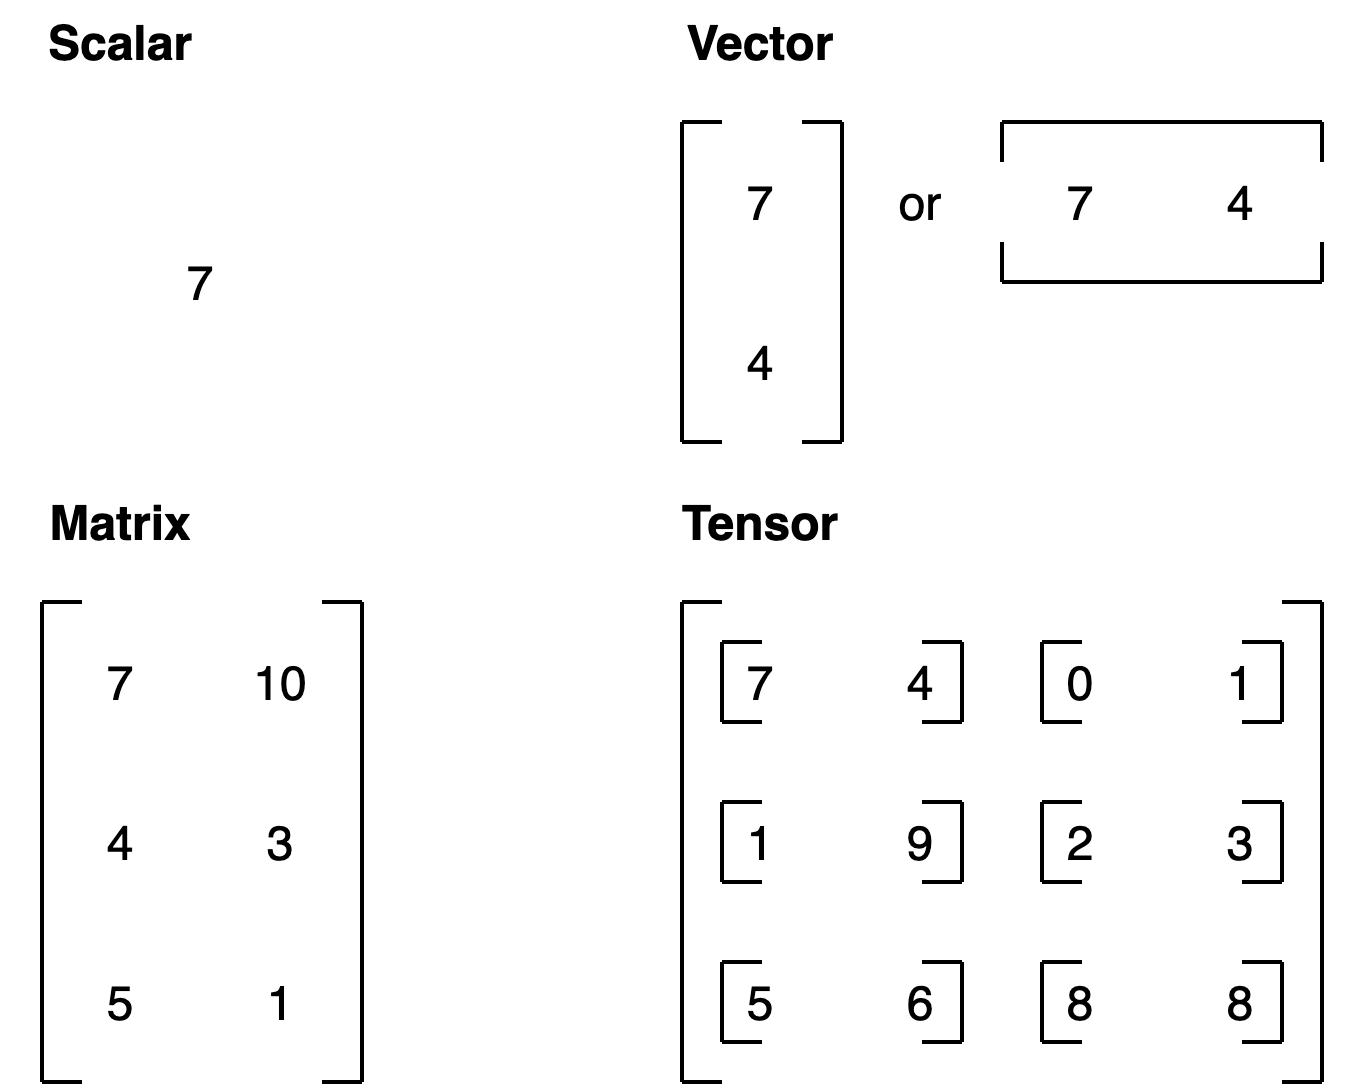

In [ ]:
# Install TensorFlow
# pip install tensorflow

# Import required libraries
import tensorflow as tf
import numpy as np

# Check TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")
# Output: TensorFlow Version: 2.x.x

# Check if GPU is available
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
# Output: GPU Available: [] (if no GPU) or [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

TensorFlow Version: 2.19.0
GPU Available: []



## TensorFlow Basics

### 1. Tensors - The Core Data Structure

In [ ]:
# Tensors are multi-dimensional arrays with a uniform type
# They are immutable - you cannot update the contents of a tensor

# Creating tensors from different sources
# 1. From Python lists
tensor_from_list = tf.constant([1, 2, 3, 4, 5])
print(f"Tensor from list: {tensor_from_list}")
# Output: Tensor from list: tf.Tensor([1 2 3 4 5], shape=(5,), dtype=int32)

# 2. From NumPy arrays
numpy_array = np.array([[1, 2], [3, 4], [5, 6]])
tensor_from_numpy = tf.constant(numpy_array)
print(f"Tensor from NumPy:\n{tensor_from_numpy}")
# Output: Tensor from NumPy:

Tensor from list: [1 2 3 4 5]
Tensor from NumPy:
[[1 2]
 [3 4]
 [5 6]]


In [ ]:
# 3. Special tensors
zeros_tensor = tf.zeros([3, 3])  # 3x3 matrix of zeros
zeros_tensor


<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

In [ ]:
ones_tensor = tf.ones([2, 4])    # 2x4 matrix of ones
ones_tensor

<tf.Tensor: shape=(2, 4), dtype=float32, numpy=
array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]], dtype=float32)>

In [ ]:
identity_matrix = tf.eye(3)      # 3x3 identity matrix
identity_matrix

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)>

In [ ]:
random_tensor = tf.random.normal([2, 3])  # Random normal distribution
random_tensor

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 0.03553157,  1.5432229 , -1.3933232 ],
       [ 1.2911049 , -0.8503296 ,  0.23714647]], dtype=float32)>

In [ ]:
### 2. Tensor Properties


# Understanding tensor properties is crucial for debugging

sample_tensor = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.float32)

# Shape: Dimensions of the tensor
print(f"Shape: {sample_tensor.shape}")
# Output: Shape: (2, 3) - 2 rows, 3 columns

# Rank: Number of dimensions
print(f"Rank: {tf.rank(sample_tensor)}")
# Output: Rank: tf.Tensor(2, shape=(), dtype=int32)

# Size: Total number of elements
print(f"Size: {tf.size(sample_tensor)}")
# Output: Size: tf.Tensor(6, shape=(), dtype=int32)

# Data type
print(f"Data type: {sample_tensor.dtype}")
# Output: Data type: <dtype: 'float32'>

Shape: (2, 3)
Rank: 2
Size: 6
Data type: <dtype: 'float32'>


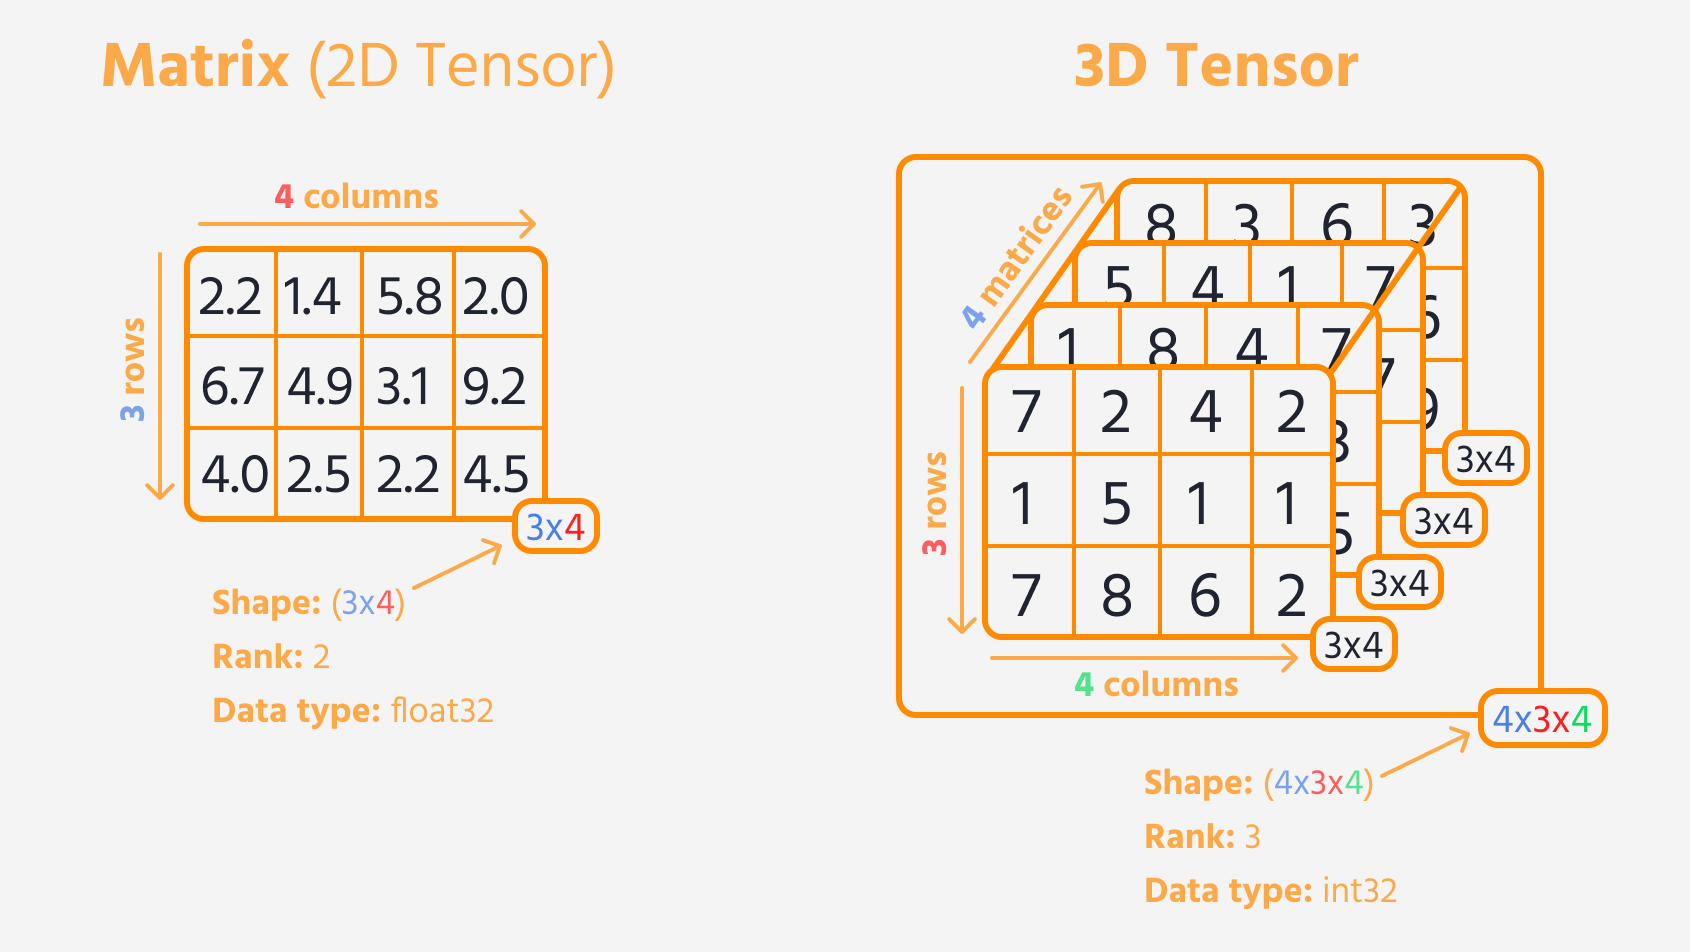

In [ ]:
## Tensor Operations

### 1. Basic Mathematical Operations


# Element-wise operations
a = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
b = tf.constant([[5, 6], [7, 8]], dtype=tf.float32)

# Addition
add_result = tf.add(a, b)  # or simply a + b
print(f"Addition:\n{add_result}")
# Output: [[6. 8.] [10. 12.]]

# Multiplication (element-wise)
multiply_result = tf.multiply(a, b)  # or a * b
print(f"Element-wise multiplication:\n{multiply_result}")
# Output: [[5. 12.] [21. 32.]]

# Matrix multiplication (dot product)
matmul_result = tf.matmul(a, b)  # or a @ b
print(f"Matrix multiplication:\n{matmul_result}")
# Output: [[19. 22.] [43. 50.]]
# Explanation: [1*5+2*7, 1*6+2*8] = [19, 22] for first row

# Reduction operations
tensor = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.float32)

Addition:
[[ 6.  8.]
 [10. 12.]]
Element-wise multiplication:
[[ 5. 12.]
 [21. 32.]]
Matrix multiplication:
[[19. 22.]
 [43. 50.]]


In [ ]:
# Reduction operations
tensor = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.float32)

# Mean across all elements
mean_all = tf.reduce_mean(tensor)
print(f"Mean of all elements: {mean_all}")
# Output: Mean of all elements: 3.5

# Sum along axis (axis=0: columns, axis=1: rows)
sum_columns = tf.reduce_sum(tensor, axis=0)
sum_rows = tf.reduce_sum(tensor, axis=1)
print(f"Sum along columns: {sum_columns}")  # Output: [5. 7. 9.]
print(f"Sum along rows: {sum_rows}")        # Output: [6. 15.]

Mean of all elements: 3.5
Sum along columns: [5. 7. 9.]
Sum along rows: [ 6. 15.]


In [ ]:
# Reshaping is crucial for preparing data for neural networks

original = tf.constant([[1, 2, 3], [4, 5, 6]])
print(f"Original shape: {original.shape}")  # Output: (2, 3)

# Reshape to different dimensions
reshaped = tf.reshape(original, [3, 2])
print(f"Reshaped to 3x2:\n{reshaped}")
# Output: [[1 2] [3 4] [5 6]]

# Flatten to 1D
flattened = tf.reshape(original, [-1])  # -1 means "infer this dimension"
print(f"Flattened: {flattened}")
# Output: [1 2 3 4 5 6]

# Transpose
transposed = tf.transpose(original)
print(f"Transposed:\n{transposed}")
# Output: [[1 4] [2 5] [3 6]]

# Expand dimensions (useful for batch processing)
expanded = tf.expand_dims(original, axis=0)  # Add batch dimension
print(f"Expanded shape: {expanded.shape}")   # Output: (1, 2, 3)



### 🔹 What’s Going On?

```python
expanded = tf.expand_dims(original, axis=0)  
```

* **`original`**: Suppose this is a tensor with shape `(2, 3)`.
  Example:

  ```python
  original = tf.constant([[1, 2, 3],
                          [4, 5, 6]])
  print(original.shape)  # (2, 3)
  ```

* **`tf.expand_dims(original, axis=0)`**:
  This *inserts* a new dimension at the specified axis (here `0`).
  So:

  * Original shape: `(2, 3)`
  * Expanded shape: `(1, 2, 3)`

* **Why "expand"?** Because machine learning models **expect data in batches**. Even if you only have one sample, you must wrap it in a batch dimension.

---

### 🔹 Visual Analogy

* Imagine you have a **single row of data** in Excel (`2x3` table).
* A neural network, however, wants data grouped into **batches**—like a folder containing multiple Excel sheets.
* By expanding dimensions, you’re putting your single row inside a folder (`1x2x3`) → meaning “1 batch of size (2x3)”.

---

### 🔹 Industry Example

1. **Image Recognition**

   * A single RGB image might have shape `(224, 224, 3)` → height, width, channels.
   * But models expect `(batch_size, height, width, channels)`.
   * If you only have **one image**, you need:

     ```python
     image = tf.random.normal([224, 224, 3])
     image_batch = tf.expand_dims(image, axis=0)
     print(image_batch.shape)  # (1, 224, 224, 3)
     ```
   * Now your model sees it as a batch of 1 image.

2. **Text Classification**

   * Suppose you have a vectorized sentence: `(10,)` tokens.

   * A model expects `(batch_size, sequence_length)`.

   * Add dimension:

     ```python
     sentence = tf.constant([5, 12, 7, 9, 1, 0, 0, 0, 0, 0])  # shape (10,)
     batched_sentence = tf.expand_dims(sentence, axis=0)
     print(batched_sentence.shape)  # (1, 10)
     ```

   * Now it’s a batch of one sentence.

---

### 🔹 Why It Matters

👉 **Batch dimension** is crucial for:

* Parallel processing on GPUs (fast training).
* Consistent input shape for models (`.fit`, `.predict`, etc.).
* Avoiding shape mismatches between training and inference.

---





### ✅ Example Tensor

```python
import tensorflow as tf

F = tf.constant([0.2, 0.8, 0.5])
print(F.numpy())  # [0.2 0.8 0.5]
```

---

### 🔹 Step 1: Find the biggest and smallest values

```python
print(tf.reduce_max(F).numpy())  # 0.8 (biggest number)
print(tf.reduce_min(F).numpy())  # 0.2 (smallest number)
```

---

### 🔹 Step 2: Find *where* (position) they are

```python
print(tf.argmax(F).numpy())  # 1 → position of biggest (0.8)
print(tf.argmin(F).numpy())  # 0 → position of smallest (0.2)
```

---

### 🔹 Step 3: Use the position to pick the value

```python
print(F[tf.argmax(F)].numpy())  # 0.8 (same as max)
```

---

### 🟢 Real-World Analogy (Prediction)

Imagine you built a model that predicts **fruit types**:
Labels → `['Apple', 'Banana', 'Cherry']`
Predictions → `[0.2, 0.8, 0.5]`

* `tf.argmax(predictions)` → `1` → Model thinks **"Banana"** is most likely 🍌
* `tf.reduce_max(predictions)` → `0.8` → Confidence is **80%**

---

👉 In short:

* `reduce_max/min` = actual value (highest or lowest)
* `argmax/argmin` = position (index) of that value




Great! Let’s keep it **short, simple, and clear** ✅ with **what it does + how to use + small example**.

---

## 🔹 1. `tf.squeeze()`

**Use:** Remove dimensions of size **1** (like "extra empty boxes").
**Why:** Makes tensors cleaner and easier to work with.

```python
import tensorflow as tf
import numpy as np

G = tf.constant(np.random.randint(0, 100, 50), shape=(1,1,1,1,50))
print(G.shape)        # (1, 1, 1, 1, 50)
G_squeezed = tf.squeeze(G)
print(G_squeezed.shape) # (50,)
```

👉 Useful when model outputs have unnecessary dimensions like `(1, 10, 1)` → squeeze → `(10,)`.

---

## 🔹 2. `tf.one_hot()`

**Use:** Turn indices (numbers) into a **one-hot encoded vector** (used in classification).
**Why:** Models need categorical data in numeric vector form.

```python
labels = [0, 1, 2, 3]
print(tf.one_hot(labels, depth=4))
# [[1,0,0,0],
#  [0,1,0,0],
#  [0,0,1,0],
#  [0,0,0,1]]
```

👉 Example: If classes = `['Cat','Dog','Fish','Bird']`, and label = `2` → one-hot → `[0,0,1,0]` → means "Fish".

You can even use custom values:

```python
print(tf.one_hot(labels))
```

---

## 🔹 3. Math Functions

### a) `tf.square()`

Squares each element.

```python
x = tf.constant([2, 3, 4], dtype=tf.float32)
print(tf.square(x))  # [4, 9, 16]
```

👉 Useful in **loss functions** (e.g., Mean Squared Error).

---

### b) `tf.sqrt()`

Square root of each element (needs floats).

```python
print(tf.sqrt([4.0, 9.0, 16.0]))  # [2, 3, 4]
```

👉 Useful for **normalization** or statistical calculations.

---

### c) `tf.math.log()`

Natural log of each element (needs floats).

```python
print(tf.math.log([1.0, 2.0, 10.0]))
# [0, 0.693..., 2.302...]
```

👉 Useful in **probabilities/log-likelihoods** (e.g., in cross-entropy loss).

---

✅ **Quick Summary Table**

| Function        | What it does                    | Example Input | Example Output                |
| --------------- | ------------------------------- | ------------- | ----------------------------- |
| `tf.squeeze()`  | Removes size-1 dimensions       | (1,1,50)      | (50,)                         |
| `tf.one_hot()`  | Converts index → one-hot vector | \[0,1,2]      | \[\[1,0,0],\[0,1,0],\[0,0,1]] |
| `tf.square()`   | Squares each element            | \[2,3,4]      | \[4,9,16]                     |
| `tf.sqrt()`     | Square root of each element     | \[4,9,16]     | \[2,3,4]                      |
| `tf.math.log()` | Natural log of each element     | \[1,2,10]     | \[0,0.69,2.30]                |





## 🔹 1. `tf.constant` vs `tf.Variable`

### ✅ `tf.constant`

* **Immutable (unchangeable)**: Once you create it, the values cannot be changed.
* Used for **fixed values** that should **never update** during training.
* Example: constants like `π`, `e`, or hyperparameters.

```python
c = tf.constant([1, 2, 3])
# c[0].assign(10) ❌ ERROR (cannot change constant)
```

---

### ✅ `tf.Variable`

* **Mutable (changeable)**: Values can be updated during computation/training.
* Used for **trainable parameters** in models (like weights & biases).
* Methods like `.assign()` and `.assign_add()` let you change values.

```python
v = tf.Variable([1, 2, 3])
v[0].assign(10)          # ✅ change first value → [10, 2, 3]
v.assign_add([1, 1, 1])  # ✅ add to each element → [11, 3, 4]
```

---

## 🔹 2. Use Cases

### 📌 `tf.constant` (fixed values)

* When values don’t change during training/inference.
* Examples:

  * Lookup tables (e.g., vocabulary indices).
  * Predefined masks or flags.
  * Fixed embeddings or coefficients.

---

### 📌 `tf.Variable` (trainable parameters)

* When values **must update** during training.
* Examples:

  * Neural network **weights & biases**.
  * Custom counters or accumulators.
  * Fine-tuning models (adjustable layers).

---

## 🔹 3. Simple Analogy

* `tf.constant` = **printed book** 📖 (once printed, can’t change).
* `tf.Variable` = **whiteboard** 🖊️ (you can erase and rewrite anytime).

---

## 🔹 4. Mini Example: Neural Network Weight Update

```python
# Constant learning rate
learning_rate = tf.constant(0.1)

# Trainable weight (starts as 5.0)
weight = tf.Variable(5.0)

# Fake gradient
gradient = 0.2

# Update step: weight = weight - lr * gradient
weight.assign(weight - learning_rate * gradient)
print(weight.numpy())  # 4.98 (updated!)
```

👉 Here, `learning_rate` is a **constant** (fixed),
while `weight` is a **variable** (trainable).

---

✅ **In short:**

* Use **`tf.constant`** for things that never change.
* Use **`tf.Variable`** for things that need to update (like model parameters).




## 🔹 What `@tf.function` Does

* A **normal Python function** runs step by step (slow, flexible).
* When you add **`@tf.function`**, TensorFlow converts that Python function into a **computational graph** (optimized, faster, portable).
* Graphs run more efficiently, can be executed on GPUs/TPUs, and even exported for production.

So it’s like going from **“handwritten notes”** ✍️ to **“compiled code”** ⚡.

---

## 🔹 Why Do We Need It?

### 1. **Performance (Speed)**

Graphs allow TensorFlow to optimize execution:

* Combine operations,
* Run in parallel,
* Use GPUs/TPUs better.

Without `@tf.function`, your code is executed line by line in Python, which is slower.

---

### 2. **Portability (Deployment)**

Graphs can be **saved** and **moved**:

* Train on your laptop,
* Export the function,
* Deploy it on a mobile app, embedded device, or a cloud server **without rewriting code**.

---

## 🔹 Industry Examples

### 📌 Example 1: Real-Time Fraud Detection (Banking)

A bank runs a TensorFlow model to decide if a transaction is fraud **in milliseconds**.

* Without `@tf.function`, Python overhead makes it too slow.
* With `@tf.function`, the model runs as a fast graph on GPUs/TPUs → faster responses → better fraud protection.

---

### 📌 Example 2: Recommendation System (E-commerce / Netflix)

Say you recommend products/movies in **real-time**:

```python
@tf.function
def predict(user_vector, item_vector):
    score = tf.reduce_sum(user_vector * item_vector, axis=1)
    return tf.nn.softmax(score)
```

* With `@tf.function`, thousands of user-item comparisons can be processed **in parallel on GPU**.
* Customers get instant recommendations.

---

### 📌 Example 3: Self-Driving Cars (Edge AI)

Self-driving cars need to run ML models **on small onboard computers**.

* With `@tf.function`, you can export your trained function as a graph (`SavedModel`) and run it efficiently on hardware chips inside the car.
* Without it, raw Python would be too slow → unsafe delays.

---

## 🔹 Simple Demo (Speedup)

```python
import tensorflow as tf
import time

def normal_fn(x):
    for _ in range(1000):
        x = tf.math.sqrt(x)
    return x

@tf.function
def graph_fn(x):
    for _ in range(1000):
        x = tf.math.sqrt(x)
    return x

x = tf.random.uniform([1000,1000])

# Measure normal
start = time.time(); normal_fn(x); print("Normal:", time.time()-start)

# Measure with graph
start = time.time(); graph_fn(x); print("Graph:", time.time()-start)
```

👉 You’ll see the `graph_fn` (with `@tf.function`) runs faster because TensorFlow optimized the loop into a graph.

---

✅ **In short:**

* `@tf.function` makes your code **faster and deployable**.
* Use it when writing functions that will run **many times** (training loops, prediction steps, preprocessing).




## 🔹 Why GPUs Matter

* **CPUs** → Good for general tasks, but slow for large ML workloads.
* **GPUs** → Designed for **parallel processing** → massively speed up tensor calculations, especially matrix multiplications used in neural networks.
* Without GPUs, training big models (like CNNs, Transformers) can take days instead of hours.

---

## 🔹 How to Check for GPU in TensorFlow

### 1. Basic Check

```python
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))
```

* If you see something like:

  ```
  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  ```

  ✅ A GPU is available.
* If it’s empty `[]` → ❌ No GPU detected.

---

### 2. In Google Colab / Jupyter

* Go to: **Runtime → Change runtime type → GPU → Save**
* Then rerun:

  ```python
  print(tf.config.list_physical_devices('GPU'))
  ```
* Now you should see the GPU.

---

### 3. Detailed GPU Info (NVIDIA only)

```bash
!nvidia-smi
```

This gives:

* GPU name (e.g., **NVIDIA A100**)
* Memory (e.g., 40 GB VRAM)
* Usage stats (temperature, power, running processes)

---

## 🔹 Industry Example: Why This Matters

1. **Computer Vision (Retail / Manufacturing)**

   * Training a defect detection model on images (say 100k product photos).
   * On CPU → days.
   * On GPU → a few hours.

2. **Finance (Fraud Detection)**

   * Model analyzing millions of transactions in real time.
   * GPU ensures fast training + inference → real-time fraud alerts.

3. **Healthcare (Medical Imaging)**

   * MRI scan analysis using CNNs.
   * Requires huge computations → GPUs make training feasible.

---

## 🔹 Good to Know

* TensorFlow **automatically uses the GPU** if one is available.
  No need to manually tell it.
* If you have multiple GPUs, you can check them:

  ```python
  tf.config.list_physical_devices('GPU')
  ```
* You can also **force CPU or GPU**:

  ```python
  with tf.device('/CPU:0'):
      a = tf.constant([1.0, 2.0])
  with tf.device('/GPU:0'):
      b = tf.constant([3.0, 4.0])
  ```

---

✅ **In short:**

* Use `tf.config.list_physical_devices('GPU')` to check for GPU.
* Use `!nvidia-smi` for detailed info.
* If GPU is available, TensorFlow automatically uses it → speeding up training & inference.





## 🛠 Practice Exercises

1. Create a **scalar, vector, matrix, and higher-rank tensor** using `tf.constant()` with values you choose.

2. For each tensor from step 1, print its **shape, rank (number of dimensions), and total elements**.

3. Generate two tensors filled with **random numbers between 0 and 1**, each of shape `[5, 200]`.

4. Perform a **matrix multiplication** of the tensors from step 3.

5. Perform an **element-wise dot product** of the tensors from step 3.

6. Create a tensor of random numbers between 0 and 1 with shape `[128, 128, 3]` (think of it like a random image).

7. Find the **smallest and largest values** inside the tensor from step 6.

8. Create a tensor of random values with shape `[1, 128, 128, 3]` and then use `tf.squeeze()` to reduce its shape to `[128, 128, 3]`.

9. Make a tensor of shape `[15]` with numbers of your choice, and find the **position (index)** of the maximum value.

10. One-hot encode the tensor you created in step 9 with a suitable `depth`.




In [ ]:

import tensorflow as tf
import numpy as np

tf.random.set_seed(42)

# 1) Create a scalar, vector, matrix, and higher-rank tensor with tf.constant()
scalar  = tf.constant(7)                               # shape: ()
vector  = tf.constant([2, 4, 6, 8])                    # shape: (4,)
matrix  = tf.constant([[1, 0, 3],
                       [4, 5, 6]])                     # shape: (2, 3)
tensor4 = tf.constant([[[[1, 2], [3, 4]]]])            # shape: (1, 1, 2, 2)

print("1) Created tensors.")
print("scalar:", scalar.numpy())
print("vector:\n", vector.numpy())
print("matrix:\n", matrix.numpy())
print("tensor4 (rank 4):\n", tensor4.numpy(), "\n")

# 2) Print shape, rank, and total size for each
def info(name, t):
    print(f"{name}: shape={t.shape}, rank={tf.rank(t).numpy()}, size={tf.size(t).numpy()}")

print("2) Shapes / Ranks / Sizes")
info("scalar", scalar)
info("vector", vector)
info("matrix", matrix)
info("tensor4", tensor4)
print()

# 3) Two random tensors in [0,1) with shape [5, 200]
A = tf.random.uniform([5, 200], minval=0., maxval=1.)
B = tf.random.uniform([5, 200], minval=0., maxval=1.)
print("3) Created A and B with shape:", A.shape, B.shape, "\n")

# 4) Matrix multiplication (make inner dims match by transposing B)
mm = tf.matmul(A, B, transpose_b=True)   # result shape: [5, 5]
print("4) Matrix multiplication A @ B^T shape:", mm.shape, "\n")

# 5) Row-wise dot product (elementwise multiply then sum over last axis)
rowwise_dot = tf.reduce_sum(A * B, axis=1)  # result shape: [5]
print("5) Row-wise dot product shape:", rowwise_dot.shape)
print("   Example values:", rowwise_dot.numpy()[:3], "\n")

# 6) Random "image-like" tensor [128, 128, 3]
img = tf.random.uniform([128, 128, 3], 0., 1.)
print("6) Random image shape:", img.shape, "\n")

# 7) Min and max of the image tensor
img_min = tf.reduce_min(img)
img_max = tf.reduce_max(img)
print("7) Image min:", img_min.numpy(), "max:", img_max.numpy(), "\n")

# 8) Create [1, 128, 128, 3] then squeeze to [128, 128, 3]
img_batch = tf.expand_dims(img, axis=0)  # shape: [1, 128, 128, 3]
img_squeezed = tf.squeeze(img_batch)     # shape: [128, 128, 3]
print("8) Before squeeze:", img_batch.shape, "After squeeze:", img_squeezed.shape, "\n")

# 9) Create [15] tensor and find index of max
vals = tf.constant([3, 7, 1, 0, 7, 9, 2, 2, 9, 8, 5, 5, 5, 1, 4], dtype=tf.int32)
argmax_idx = tf.argmax(vals)
print("9) vals:", vals.numpy())
print("   Index of max:", argmax_idx.numpy(), "Max value:", vals[argmax_idx].numpy(), "\n")

# 10) One-hot encode the tensor from step 9
depth = 10  # at least max(vals)+1 (max is 9 here)
one_hot = tf.one_hot(vals, depth=depth)
print("10) One-hot shape:", one_hot.shape)
print("    First 3 rows:\n", one_hot.numpy()[:3])
